# 02 — From Scratch: Attention, Multi-Head Attention, Positional Encoding

Implementation จริง (numpy) — cross-check ตัวเลขกับที่คำนวณด้วยมือใน [`01_concept.ipynb`](01_concept.ipynb)

## 1. Objective

Implement จากพื้นฐาน (ตาม From-Scratch Rule ใน `AGENTS.md` §16) แล้ว **verify ว่าถูกต้อง** ด้วยการ
เทียบผลกับตัวเลขที่คำนวณด้วยมือใน `01_concept.ipynb` ก่อนจะเปรียบเทียบกับ `torch.nn.functional`
ใน `03_experiment.ipynb`:

1. Scaled Dot-Product Attention
2. Multi-Head Attention
3. Sinusoidal Positional Encoding

## 2. Prerequisites

อ่าน [`01_concept.ipynb`](01_concept.ipynb) ให้จบก่อน โดยเฉพาะ hypothesis ในหัวข้อ 3 และตัวอย่างคำนวณ
ในหัวข้อ 5 — ตัวเลขในโน้ตบุ๊กนี้จะถูกเทียบกับตัวเลขจากที่นั่นโดยตรง

## 3. Dependency Note

ใช้ **numpy** (มีอยู่แล้วใน `pyproject.toml`) ไม่ใช่ `torch` — เหตุผล (ตามเกณฑ์ `AGENTS.md` §27):
numpy เพียงพอสำหรับสาธิต **algorithm** (matrix multiply, softmax, indexing) แบบ vectorized ได้ครบ
โดยไม่ต้องแบก autograd/tensor overhead ที่ torch มีมาให้ ซึ่งยังไม่จำเป็นในขั้นตอนนี้เพราะเรายังไม่ train
อะไร (weight ในโน้ตบุ๊กนี้คือ random projection คงที่ ไม่มีการอัปเดต) — `torch` จะถูกพิจารณาเพิ่มเมื่อ
lab ต้องการ train จริง (backprop ผ่าน weight ที่เรียนรู้ได้)

In [10]:
# P0 - Reproducibility (AGENTS.md #14)
import random

import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
rng = np.random.default_rng(SEED)

## 4. Implementation — Scaled Dot-Product Attention

```text
Attention(Q, K, V) = softmax(QKᵀ / √d_k) V
```

**ทางเลือกการ implement ที่ต้องตัดสินใจ:**

- **numerical stability**: `exp()` ของค่าที่ใหญ่มากจะ overflow — ต้องลบค่า max ต่อแถวออกก่อนเข้า `exp`
  (`softmax(x) = softmax(x - max(x))` เป็นสมการเดียวกันทางคณิตศาสตร์ เพราะค่าคงที่หักล้างกันตอนหารผลรวม
  แต่กันไม่ให้ `exp` ระเบิดค่า)
- **mask ก่อน scale หรือหลัง**: mask ต้องใส่ **หลัง** scale และ **ก่อน** softmax เสมอ (ใส่เป็น `-inf`
  ที่ตำแหน่งที่ห้ามมองเห็น เพื่อให้ softmax ให้น้ำหนัก 0 ที่ตำแหน่งนั้นพอดี)
- **รองรับ batch/multi-head ด้วย broadcasting**: เขียนให้ `q`, `k`, `v` รับมิติเพิ่มด้านหน้าได้ (เช่น
  `[batch, n, d]` หรือ `[heads, n, d]`) โดยไม่ต้องเขียนโค้ดแยก — ใช้ `...` (ellipsis) ใน numpy indexing
  แทนการเขียน loop ซ้อน

In [11]:
# P0 - Core implementation of scaled dot-product attention.
def scaled_dot_product_attention(
    q: np.ndarray,
    k: np.ndarray,
    v: np.ndarray,
    mask: np.ndarray | None = None,
) -> tuple[np.ndarray, np.ndarray]:
    """
    q: [..., n_q, d_k]
    k: [..., n_k, d_k]
    v: [..., n_k, d_v]
    mask: [..., n_q, n_k], True = masked out (optional)
    returns: output [..., n_q, d_v], weights [..., n_q, n_k]
    """
    d_k = q.shape[-1]
    scores = q @ np.swapaxes(k, -1, -2) / np.sqrt(d_k)  # [..., n_q, n_k]

    if mask is not None:
        scores = np.where(mask, -np.inf, scores)

    scores = scores - np.max(scores, axis=-1, keepdims=True)  # numerical stability
    exp_scores = np.exp(scores)
    weights = exp_scores / np.sum(exp_scores, axis=-1, keepdims=True)  # [..., n_q, n_k]

    output = weights @ v  # [..., n_q, d_v]
    return output, weights

### 4.1 Verify: ผลลัพธ์ต้องตรงกับที่คำนวณด้วยมือใน `01_concept.ipynb`

ใช้ `Q`, `K`, `V` ชุดเดียวกันเป๊ะจาก `01_concept.ipynb` หัวข้อ 5 — ถ้า implementation ถูกต้อง
ตัวเลขต้องตรงกับที่พิมพ์ไว้ที่นั่น: attention weight แถวแรก `[0.506, 0.186, 0.307]`,
output แถวแรก `[0.506, 0.186, 0.307]`

In [12]:
# P3 - Cross-check against the hand-worked numbers from 01_concept.ipynb section 5.
Q_toy = np.array([[1.0, 0.0, 1.0, 0.0], [0.0, 1.0, 0.0, 1.0]])
K_toy = np.array([[1.0, 0.0, 1.0, 0.0], [0.0, 1.0, 0.0, 1.0], [1.0, 1.0, 0.0, 0.0]])
V_toy = np.array([[1.0, 0.0, 0.0], [0.0, 1.0, 0.0], [0.0, 0.0, 1.0]])

output_toy, weights_toy = scaled_dot_product_attention(Q_toy, K_toy, V_toy)

expected_weights_row0 = np.array([0.506, 0.186, 0.307])
print("weights:\n", np.round(weights_toy, 3))
print("output:\n", np.round(output_toy, 3))
print("row sums:", np.round(weights_toy.sum(axis=-1), 6))

assert np.allclose(weights_toy[0], expected_weights_row0, atol=1e-3), (
    "Mismatch vs. 01_concept.ipynb hand-worked example"
)
print("\nMatches 01_concept.ipynb hand-worked example (atol=1e-3).")

weights:
 [[0.506 0.186 0.307]
 [0.186 0.506 0.307]]
output:
 [[0.506 0.186 0.307]
 [0.186 0.506 0.307]]
row sums: [1. 1.]

Matches 01_concept.ipynb hand-worked example (atol=1e-3).


## 5. Implementation — Multi-Head Attention

Base model: `h=8`, `d_k=d_v=d_model/h=64` (ดูที่มาใน [`01_concept.ipynb`](01_concept.ipynb) §4.6)

**ทางเลือกการ implement:** เขียนเป็น loop ต่อ head แทนที่จะ reshape เป็น tensor เดียวแล้ว vectorize
ข้าม head ทั้งหมด — ช้ากว่าในทางปฏิบัติ แต่ **อ่านง่ายกว่าและ debug ง่ายกว่า** เหมาะกับจุดประสงค์การเรียนรู้
ของโน้ตบุ๊กนี้ (ตาม "Preserve Learning Value", `AGENTS.md` §38) เวอร์ชัน production จริงจะ reshape
`[n, d_model]` เป็น `[h, n, d_k]` ครั้งเดียวแล้วใช้ batched matmul แทน loop

**สำคัญ:** `W_Q`, `W_K`, `W_V`, `W_O` ในเซลล์นี้เป็น **random projection ที่ตรึงไว้ ไม่ได้ train**
— ใช้สาธิตว่าโครงสร้าง multi-head ทำงานถูกต้องเชิง shape/algorithm เท่านั้น ไม่ได้แปลว่าแต่ละ head
เรียนรู้ pattern ที่มีความหมายจริง (นั่นต้องผ่าน training)

In [13]:
# P0 - Core implementation of multi-head attention.
def multi_head_attention(
    x_q: np.ndarray,
    x_k: np.ndarray,
    x_v: np.ndarray,
    num_heads: int,
    d_model: int,
    rng: np.random.Generator,
    mask: np.ndarray | None = None,
) -> tuple[np.ndarray, list[np.ndarray]]:
    """
    x_q: [n_q, d_model]
    x_k, x_v: [n_k, d_model]
    returns: output [n_q, d_model], list of per-head weights (len num_heads, each [n_q, n_k])
    """
    assert d_model % num_heads == 0, "d_model must be divisible by num_heads"
    d_k = d_model // num_heads
    d_v = d_k

    # Random, untrained projections -- see note above.
    w_q = rng.normal(0, 0.1, size=(num_heads, d_model, d_k))
    w_k = rng.normal(0, 0.1, size=(num_heads, d_model, d_k))
    w_v = rng.normal(0, 0.1, size=(num_heads, d_model, d_v))
    w_o = rng.normal(0, 0.1, size=(num_heads * d_v, d_model))

    head_outputs = []
    head_weights = []
    for h in range(num_heads):
        q_h = x_q @ w_q[h]  # [n_q, d_k]
        k_h = x_k @ w_k[h]  # [n_k, d_k]
        v_h = x_v @ w_v[h]  # [n_k, d_v]
        out_h, w_h = scaled_dot_product_attention(q_h, k_h, v_h, mask=mask)
        head_outputs.append(out_h)
        head_weights.append(w_h)

    concat = np.concatenate(head_outputs, axis=-1)  # [n_q, num_heads * d_v]
    output = concat @ w_o  # [n_q, d_model]
    return output, head_weights

In [14]:
# P3 - Sanity check: output shape stays [n, d_model] regardless of num_heads (AGENTS.md #18).
n, d_model = 6, 16
x = rng.normal(size=(n, d_model))

for h in (1, 2, 4, 8):
    out, head_ws = multi_head_attention(x, x, x, num_heads=h, d_model=d_model, rng=rng)
    assert out.shape == (n, d_model), f"h={h}: got shape {out.shape}"
    assert len(head_ws) == h
    assert head_ws[0].shape == (n, n)
    print(f"h={h}: output shape={out.shape}, per-head weight shape={head_ws[0].shape}  OK")

h=1: output shape=(6, 16), per-head weight shape=(6, 6)  OK
h=2: output shape=(6, 16), per-head weight shape=(6, 6)  OK
h=4: output shape=(6, 16), per-head weight shape=(6, 6)  OK
h=8: output shape=(6, 16), per-head weight shape=(6, 6)  OK


## 6. Implementation — Sinusoidal Positional Encoding

```text
PE(pos, 2i)   = sin(pos / 10000^(2i/d_model))
PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))
```

**ทางเลือกการ implement:** คำนวณ `angle_rates` (ตัวหาร `10000^(2i/d_model)`) แยกจาก `angles`
(`position * angle_rate`) ก่อน แล้วค่อยเลือกว่ามิติคู่ใช้ `sin` มิติคี่ใช้ `cos` — เขียนเป็น vectorized
operation เดียวแทนการวน loop ทีละตำแหน่งทีละมิติ (ซึ่งจะช้ามากเมื่อ `seq_len`/`d_model` โต)

In [15]:
# P0 - Core implementation of sinusoidal positional encoding.
def positional_encoding(seq_len: int, d_model: int) -> np.ndarray:
    """returns: PE [seq_len, d_model]"""
    position = np.arange(seq_len)[:, None]  # [seq_len, 1]
    dim = np.arange(d_model)[None, :]  # [1, d_model]
    angle_rates = 1.0 / np.power(10000.0, (2 * (dim // 2)) / d_model)  # [1, d_model]
    angles = position * angle_rates  # [seq_len, d_model]

    pe = np.zeros((seq_len, d_model))
    pe[:, 0::2] = np.sin(angles[:, 0::2])
    pe[:, 1::2] = np.cos(angles[:, 1::2])
    return pe


pe_toy = positional_encoding(seq_len=4, d_model=8)
print("PE(4, 8):\n", np.round(pe_toy, 3))
assert pe_toy.shape == (4, 8)
assert np.allclose(pe_toy[0, 0::2], 0.0)  # sin(0) = 0 at position 0
assert np.allclose(pe_toy[0, 1::2], 1.0)  # cos(0) = 1 at position 0
print("Shape and boundary values OK (position 0: sin=0, cos=1).")

PE(4, 8):
 [[ 0.     1.     0.     1.     0.     1.     0.     1.   ]
 [ 0.841  0.54   0.1    0.995  0.01   1.     0.001  1.   ]
 [ 0.909 -0.416  0.199  0.98   0.02   1.     0.002  1.   ]
 [ 0.141 -0.99   0.296  0.955  0.03   1.     0.003  1.   ]]
Shape and boundary values OK (position 0: sin=0, cos=1).


## 7. Visualization — Positional Encoding

หนึ่งในภาพที่ช่วยความเข้าใจ Positional Encoding ได้มากที่สุด: heatmap ของ `PE` matrix เต็ม ๆ
และ line plot ของบางมิติ เพื่อดู wavelength ที่ต่างกันตามที่อธิบายไว้ใน
[`../docs/paper-notes.md`](../docs/paper-notes.md) หัวข้อ 7

(หมายเหตุ: label ในกราฟใช้ภาษาอังกฤษ เพราะ default font ของ matplotlib ไม่มี glyph ภาษาไทย —
ดูที่มาของข้อจำกัดนี้ใน `01_concept.ipynb` cell แรกของหัวข้อ 4.5)

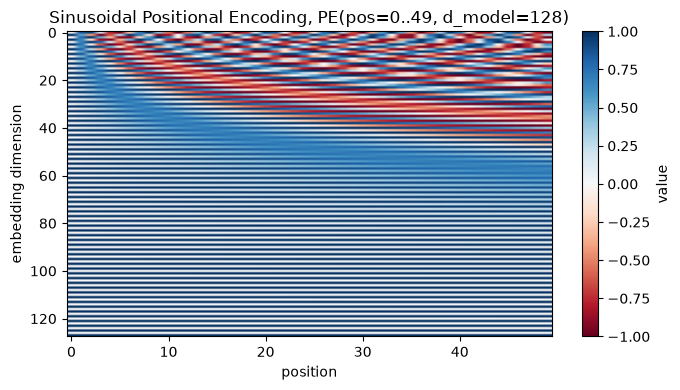

In [16]:
# P2 - Visualize the full positional encoding matrix as a heatmap.
import matplotlib.pyplot as plt

pe_full = positional_encoding(seq_len=50, d_model=128)

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(pe_full.T, aspect="auto", cmap="RdBu", vmin=-1, vmax=1)
ax.set_xlabel("position")
ax.set_ylabel("embedding dimension")
ax.set_title("Sinusoidal Positional Encoding, PE(pos=0..49, d_model=128)")
fig.colorbar(im, ax=ax, label="value")
fig.tight_layout()
plt.show()

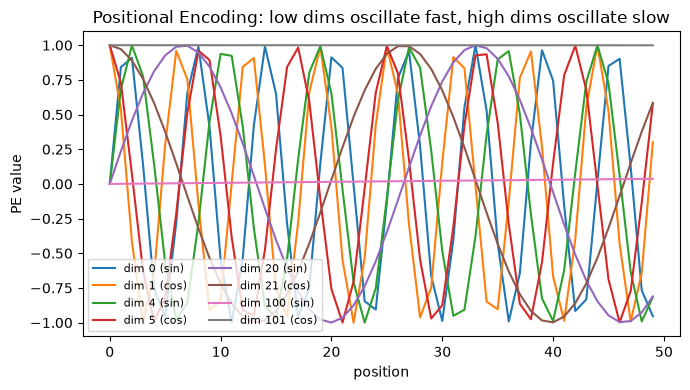

In [17]:
# P2 - Visualize a few individual dimensions to show different wavelengths.
dims_to_plot = [0, 1, 4, 5, 20, 21, 100, 101]

fig, ax = plt.subplots(figsize=(7, 4))
for d in dims_to_plot:
    ax.plot(pe_full[:, d], label=f"dim {d} ({'sin' if d % 2 == 0 else 'cos'})")
ax.set_xlabel("position")
ax.set_ylabel("PE value")
ax.set_title("Positional Encoding: low dims oscillate fast, high dims oscillate slow")
ax.legend(fontsize=8, ncol=2)
fig.tight_layout()
plt.show()

**อ่านกราฟอย่างไร:** ใน heatmap แถบสีจะ "บีบ" ถี่ขึ้นเรื่อย ๆ เมื่อเลื่อนขึ้นไปทาง dimension ต่ำ (แถวบน)
และ "ยืด" กว้างขึ้นเมื่อเลื่อนลงมาทาง dimension สูง (แถวล่าง) — ตรงกับสมการที่ตัวหาร `10000^(2i/d_model)`
เล็กเมื่อ `i` น้อย (ทำให้ `angle` โตเร็ว → คลื่นถี่) และใหญ่เมื่อ `i` มาก (ทำให้ `angle` โตช้า → คลื่นห่าง)

ในกราฟเส้น สังเกตว่า dim 0–1 (คลื่นเร็วที่สุด) วนครบรอบภายในไม่กี่ตำแหน่ง ในขณะที่ dim 100–101
แทบไม่ขยับเลยตลอด 50 ตำแหน่งที่พล็อต — ทุกมิติที่ตำแหน่ง `pos` มีค่าเฉพาะตัวจากการผสมของคลื่นความถี่ต่างกัน
หลายชุดพร้อมกัน ทำให้แต่ละตำแหน่งมี "ลายเซ็น" (encoding) ที่ไม่ซ้ำกัน แม้ว่าคลื่นแต่ละเส้นเดี่ยว ๆ
จะวนซ้ำ (periodic) ก็ตาม

## 8. Visualization — Multi-Head Attention Patterns

ทดสอบว่า head ที่ต่างกัน (แม้ยังไม่ train) ให้ attention weight ที่ **ต่างกันจริง** ตามโครงสร้าง
multi-head ที่อธิบายไว้ใน [`01_concept.ipynb`](01_concept.ipynb) §4.6 — **คำเตือน:** นี่แค่ยืนยันว่า
โครงสร้างเปิดโอกาสให้แต่ละ head ต่างกันได้ (เพราะ random projection ต่างกัน) **ไม่ใช่หลักฐานว่า
head เรียนรู้บทบาทที่มีความหมาย** — นั่นต้องมาจาก training บนข้อมูลจริงเท่านั้น

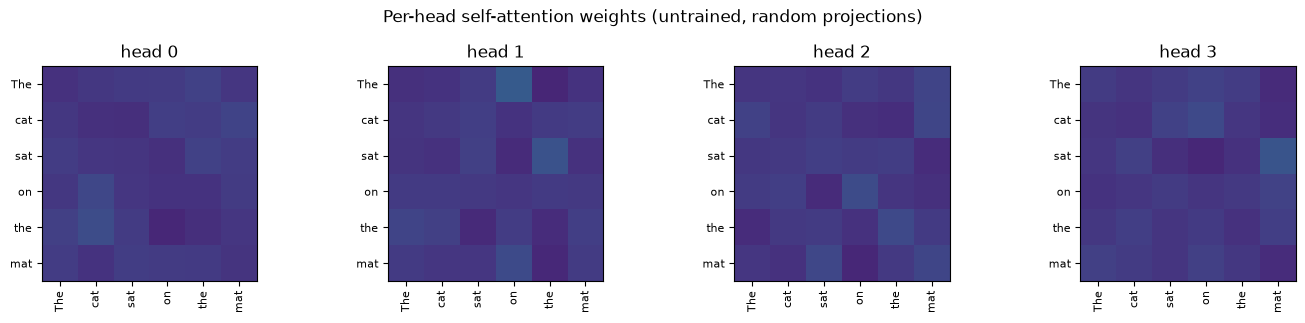

In [18]:
# P2 - Visualize per-head attention weights (untrained, random projections).
tokens = ["The", "cat", "sat", "on", "the", "mat"]
n = len(tokens)
d_model = 16
x_demo = rng.normal(size=(n, d_model))

_, head_weights_demo = multi_head_attention(
    x_demo, x_demo, x_demo, num_heads=4, d_model=d_model, rng=rng
)

fig, axes = plt.subplots(1, 4, figsize=(14, 3.2))
for h, (ax, w) in enumerate(zip(axes, head_weights_demo, strict=True)):
    im = ax.imshow(w, cmap="viridis", vmin=0, vmax=1)
    ax.set_xticks(range(n))
    ax.set_xticklabels(tokens, rotation=90, fontsize=8)
    ax.set_yticks(range(n))
    ax.set_yticklabels(tokens, fontsize=8)
    ax.set_title(f"head {h}")
fig.suptitle("Per-head self-attention weights (untrained, random projections)")
fig.tight_layout()
plt.show()

**อ่านผลลัพธ์อย่างไร:** ทั้ง 4 panel เป็น self-attention บนประโยคเดียวกัน (`x_demo` ตัวเดียวกันหมด)
แต่ pattern ของแต่ละ head **ไม่เหมือนกัน** — บาง head อาจดูกระจายเกือบเท่ากันทุกตำแหน่ง (variance ต่ำ
ในค่า projection ที่สุ่มมา) บาง head อาจดูโดดเด่นที่บางตำแหน่งชัดเจนกว่า นี่คือผลโดยตรงจากการที่แต่ละ head
มี `W_Q`, `W_K` เป็นของตัวเอง (คนละชุด random) — ยืนยันเชิง **โครงสร้าง** (structural) ว่า multi-head
ไม่ได้บังคับให้ทุกหัวเห็นอะไรเหมือนกันหมด สอดคล้องกับเหตุผลใน 01_concept §4.6 ว่าทำไม multi-head
ถึงเปิดโอกาสให้เกิด representation diversity ได้ — แต่ **ระดับที่ diversity นั้นมีความหมายจริง**
รอการยืนยันด้วย training จริงเท่านั้น (ไม่ใช่จากโน้ตบุ๊กนี้)

## 9. Extract to `shared/src` (Reuse)

`03_experiment.ipynb` ต้องใช้ `scaled_dot_product_attention` ตัวเดียวกันนี้อีกครั้งเพื่อเทียบกับ
`torch.nn.functional.scaled_dot_product_attention` — พอ logic เดียวกันถูกใช้ครั้งที่สอง ตาม
`AGENTS.md` §11 ("If meaningful implementation logic is reused for a second experiment, consider
extracting it from the notebook") จึงย้าย implementation ทั้งสามฟังก์ชันไปไว้ที่
[`shared/src/attention/`](../../../shared/src/attention/) แทนที่จะ copy-paste ซ้ำ

โค้ดในเซลล์ด้านบนยังอยู่ครบ (ตั้งใจเก็บไว้เพื่อคุณค่าการเรียนรู้ — เห็นกระบวนการ derive ทีละขั้น)
เซลล์ถัดไปแค่ import เวอร์ชันที่ extract แล้ว และ verify ว่าให้ผลลัพธ์ **เหมือนกันทุกประการ**
กับเวอร์ชัน inline ในโน้ตบุ๊กนี้ — เป็นการเช็คว่าการ extract ไม่ได้ทำให้พฤติกรรมเปลี่ยนไปโดยไม่ตั้งใจ

In [19]:
# P1 - Import the extracted shared/src/attention module and verify it matches this notebook exactly.
import sys
from pathlib import Path

shared_src = Path.cwd().resolve().parents[2] / "shared" / "src"
if str(shared_src) not in sys.path:
    sys.path.insert(0, str(shared_src))

# These imports must follow the sys.path setup above, hence the noqa.
from attention import (  # noqa: E402, I001
    multi_head_attention as shared_multi_head_attention,
    positional_encoding as shared_positional_encoding,
    scaled_dot_product_attention as shared_scaled_dot_product_attention,
)

shared_output, shared_weights = shared_scaled_dot_product_attention(Q_toy, K_toy, V_toy)
assert np.allclose(shared_output, output_toy)
assert np.allclose(shared_weights, weights_toy)

assert np.allclose(shared_positional_encoding(4, 8), pe_toy)

rng_inline = np.random.default_rng(123)
rng_shared = np.random.default_rng(123)
out_inline, _ = multi_head_attention(x, x, x, num_heads=4, d_model=d_model, rng=rng_inline)
out_shared, _ = shared_multi_head_attention(x, x, x, num_heads=4, d_model=d_model, rng=rng_shared)
assert np.allclose(out_inline, out_shared)

print("shared/src/attention matches all inline implementations in this notebook.")

shared/src/attention matches all inline implementations in this notebook.


## 10. Implementation — Position-wise Feed-Forward Network

```text
FFN(x) = max(0, x W₁ + b₁) W₂ + b₂
```

Attention ทำหน้าที่ "ผสมข้อมูลข้ามตำแหน่ง" (mixing across positions) แต่ตัวมันเองเป็น **linear operation
ล้วน ๆ** ต่อ value (weighted sum) — ถ้ามีแต่ attention ซ้อนกันหลายชั้น โมเดลทั้งก้อนก็ยังเทียบเท่า
linear transformation เดียว FFN คือส่วนที่ใส่ **non-linearity** (ReLU) เข้ามา และประมวลผล
**แต่ละตำแหน่งแยกกันโดยอิสระ** (position-wise — ตำแหน่งหนึ่งไม่เห็นอีกตำแหน่ง)

แบ่งหน้าที่กันชัดเจน:

```text
Multi-Head Attention  →  ผสมข้อมูล "ข้ามตำแหน่ง" (แต่ linear)
        ↓
Position-wise FFN     →  แปลงข้อมูล "ภายในตำแหน่ง" (แต่ non-linear)
```

**สังเกตขนาด:** `d_ff = 2048` = 4 เท่าของ `d_model = 512` — ชั้นกลางถูกขยายกว้างขึ้น 4 เท่าก่อนบีบกลับ
(อัตราส่วน 4× นี้กลายเป็นค่ามาตรฐานที่โมเดลรุ่นหลังส่วนใหญ่ยังใช้ตาม) และ FFN นี่แหละที่กิน parameter
ส่วนใหญ่ของโมเดล — มากกว่าส่วน attention เสียอีก

In [ ]:
# P0 - Core implementation of the position-wise feed-forward network.
def position_wise_ffn(
    x: np.ndarray,
    w1: np.ndarray,
    b1: np.ndarray,
    w2: np.ndarray,
    b2: np.ndarray,
) -> np.ndarray:
    """
    x:  [n, d_model]
    w1: [d_model, d_ff],  b1: [d_ff]
    w2: [d_ff, d_model],  b2: [d_model]
    returns: [n, d_model]
    """
    hidden = np.maximum(0.0, x @ w1 + b1)  # ReLU -> [n, d_ff]
    return hidden @ w2 + b2  # [n, d_model]


# Base-model dimensions from the paper (../docs/paper-notes.md section 6)
d_model_base, d_ff_base = 512, 2048
n_tokens = 6

x_ffn = rng.normal(size=(n_tokens, d_model_base))
w1 = rng.normal(0, 0.02, size=(d_model_base, d_ff_base))
b1 = np.zeros(d_ff_base)
w2 = rng.normal(0, 0.02, size=(d_ff_base, d_model_base))
b2 = np.zeros(d_model_base)

out_ffn = position_wise_ffn(x_ffn, w1, b1, w2, b2)
print(f"input  {x_ffn.shape} -> hidden [n, {d_ff_base}] -> output {out_ffn.shape}")
assert out_ffn.shape == x_ffn.shape, "FFN must preserve [n, d_model]"

# Each position is processed independently: feeding one row alone gives the same result.
single = position_wise_ffn(x_ffn[2:3], w1, b1, w2, b2)
assert np.allclose(single, out_ffn[2:3]), "FFN must be position-wise (no cross-position mixing)"
print("Position-wise property verified: row 2 alone == row 2 within the batch.")

ffn_params = w1.size + b1.size + w2.size + b2.size
attn_params = 4 * d_model_base * d_model_base  # W_Q, W_K, W_V, W_O for one layer
print(f"\nparameters per layer -> FFN: {ffn_params:,} | attention: {attn_params:,}")
print(f"FFN holds {ffn_params / (ffn_params + attn_params):.0%} of this layer's parameters")

## 11. Implementation — Add & Norm (Residual + Layer Normalization)

ทุก sub-layer ใน Transformer ถูกห่อด้วยสูตรเดียวกัน:

```text
LayerNorm(x + Sublayer(x))
```

**สองส่วนนี้แก้คนละปัญหา:**

- **Residual (`x + ...`)** — เปิด "ทางลัด" ให้ gradient ไหลย้อนกลับได้โดยไม่ต้องผ่าน sub-layer
  ถ้าไม่มี residual การซ้อน 6 layer (หรือ 96 layer ในโมเดลยุคหลัง) จะทำให้ gradient หายไประหว่างทาง
  (vanishing gradient) นอกจากนี้มันยังทำให้ sub-layer เรียนรู้แค่ "ส่วนต่าง" (residual) ที่ต้องเพิ่มเข้าไป
  แทนที่จะต้องสร้าง representation ใหม่ทั้งหมด ซึ่งเป็นงานที่ง่ายกว่ามาก
- **LayerNorm** — ทำให้ค่าในแต่ละตำแหน่ง (normalize ตามแกน feature ของ token นั้น ๆ)
  มี mean 0 variance 1 ก่อนส่งเข้า layer ถัดไป กันไม่ให้ค่าสะสมโตขึ้น/เล็กลงเรื่อย ๆ ตามความลึก

**หมายเหตุสำคัญ — post-norm vs pre-norm:** paper ต้นฉบับใช้ **post-norm** (normalize *หลัง* บวก residual
ตามสมการข้างบน) แต่โมเดลยุคหลังส่วนใหญ่เปลี่ยนไปใช้ **pre-norm** (`x + Sublayer(LayerNorm(x))`)
เพราะ train ได้เสถียรกว่าที่ความลึกมาก ๆ — โค้ดข้างล่างทำตาม paper (post-norm)
ประเด็นนี้คือคำถามเปิดข้อ 7 ใน [`../docs/open-questions.md`](../docs/open-questions.md)

In [ ]:
# P0 - Core implementation of layer normalization and the Add & Norm wrapper.
def layer_norm(
    x: np.ndarray,
    gamma: np.ndarray,
    beta: np.ndarray,
    eps: float = 1e-6,
) -> np.ndarray:
    """
    x: [..., d_model] -- normalized over the LAST axis (per token, not per batch)
    gamma, beta: [d_model] learned scale/shift
    """
    mean = x.mean(axis=-1, keepdims=True)
    var = x.var(axis=-1, keepdims=True)
    return gamma * (x - mean) / np.sqrt(var + eps) + beta


def add_and_norm(
    x: np.ndarray,
    sublayer_out: np.ndarray,
    gamma: np.ndarray,
    beta: np.ndarray,
) -> np.ndarray:
    """post-norm as in the paper: LayerNorm(x + Sublayer(x))"""
    return layer_norm(x + sublayer_out, gamma, beta)


gamma = np.ones(d_model_base)
beta = np.zeros(d_model_base)

# Feed a deliberately badly-scaled input to show what normalization fixes.
x_skewed = rng.normal(loc=50.0, scale=20.0, size=(n_tokens, d_model_base))
normed = layer_norm(x_skewed, gamma, beta)

print(f"before LayerNorm: mean={x_skewed.mean():8.3f}  std={x_skewed.std():7.3f}")
print(f"after  LayerNorm: mean={normed.mean():8.3f}  std={normed.std():7.3f}")
assert np.allclose(normed.mean(axis=-1), 0.0, atol=1e-6)
assert np.allclose(normed.std(axis=-1), 1.0, atol=1e-3)
print("Per-token mean=0, std=1 verified.")

# Full sub-layer: attention output wrapped by Add & Norm.
attn_out, _ = scaled_dot_product_attention(x_ffn, x_ffn, x_ffn)
sublayer_out = add_and_norm(x_ffn, attn_out, gamma, beta)
print(f"\nsub-layer: x {x_ffn.shape} + Attention(x) -> Add & Norm -> {sublayer_out.shape}")
assert sublayer_out.shape == x_ffn.shape

## 12. Implementation — Masking (Padding Mask & Causal Mask)

`scaled_dot_product_attention` ของเรารับพารามิเตอร์ `mask` มาตั้งแต่หัวข้อ 4 แล้ว แต่ยังไม่เคยสร้าง mask
จริงมาใช้เลย — หัวข้อนี้เติมส่วนที่ขาด เพราะ mask คือสิ่งที่ทำให้ Transformer ทำงานได้จริงในสองสถานการณ์:

**1. Padding Mask** — ประโยคในหนึ่ง batch ยาวไม่เท่ากัน ต้องเติม `<pad>` ให้ยาวเท่ากันก่อนทำเป็น tensor
ถ้าไม่ mask ตำแหน่ง `<pad>` ทิ้ง โมเดลจะ "ให้ความสนใจ" กับ token ที่ไม่มีความหมายจริง และดึงข้อมูลขยะเข้ามา

**2. Causal Mask (subsequent mask)** — ตอน train decoder เราป้อนทั้งประโยคเป้าหมายเข้าไปพร้อมกัน
เพื่อความเร็ว (ขนานได้) แต่ต้องกันไม่ให้ตำแหน่งที่ `i` มองเห็นตำแหน่ง `i+1` เป็นต้นไป มิฉะนั้นโมเดลจะ
"เห็นเฉลย" — เรียนรู้ที่จะลอกคำตอบจากอนาคตแทนที่จะทำนาย และจะพังทันทีตอน inference จริงที่ยังไม่มีอนาคตให้ดู

**กลไกทำงานอย่างไร:** ใส่ `-∞` ลงในตำแหน่งที่ต้องห้าม **หลัง** scale แต่ **ก่อน** softmax
เพราะ `exp(-∞) = 0` พอดี น้ำหนักหลัง softmax ที่ตำแหน่งนั้นจึงเป็น 0 เป๊ะ ๆ และเนื่องจาก softmax
หารด้วยผลรวม น้ำหนักที่เหลือจะถูก normalize ให้รวมกันได้ 1 ใหม่โดยอัตโนมัติ

In [ ]:
# P0 - Core implementation of padding and causal masks.
PAD_ID = 0


def padding_mask(token_ids: np.ndarray, pad_id: int = PAD_ID) -> np.ndarray:
    """
    token_ids: [n_k]
    returns: [1, n_k] -- True where the key position is padding (to be masked out).
    Broadcasts over all query rows.
    """
    return (token_ids == pad_id)[None, :]


def causal_mask(n: int) -> np.ndarray:
    """
    returns: [n, n] -- True strictly above the diagonal (future positions to mask out).
    Row i may attend to columns 0..i only.
    """
    return np.triu(np.ones((n, n), dtype=bool), k=1)


# Toy sequence: 4 real tokens then 2 <pad>
token_ids = np.array([5, 8, 3, 9, PAD_ID, PAD_ID])
seq_len = len(token_ids)

x_mask_demo = rng.normal(size=(seq_len, 32))

_, w_none = scaled_dot_product_attention(x_mask_demo, x_mask_demo, x_mask_demo)
_, w_pad = scaled_dot_product_attention(
    x_mask_demo, x_mask_demo, x_mask_demo, mask=padding_mask(token_ids)
)
_, w_causal = scaled_dot_product_attention(
    x_mask_demo, x_mask_demo, x_mask_demo, mask=causal_mask(seq_len)
)

print("padding mask (True = masked):", padding_mask(token_ids).astype(int))
print("\ncausal mask (True = masked):\n", causal_mask(seq_len).astype(int))

# The guarantees that matter:
assert np.allclose(w_pad[:, 4:], 0.0), "padding positions must receive exactly zero weight"
assert np.allclose(np.triu(w_causal, k=1), 0.0), "future positions must receive exactly zero weight"
assert np.allclose(w_pad.sum(axis=-1), 1.0), "rows must still sum to 1 after masking"
assert np.allclose(w_causal.sum(axis=-1), 1.0), "rows must still sum to 1 after masking"
print("\nVerified: masked positions are exactly 0, and every row still sums to 1.")

In [ ]:
# P2 - Visualize the effect of each mask on the attention weight matrix.
labels = ["tok0", "tok1", "tok2", "tok3", "<pad>", "<pad>"]
panels = [
    (w_none, "no mask"),
    (w_pad, "padding mask"),
    (w_causal, "causal mask"),
]

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, (w, title) in zip(axes, panels, strict=True):
    im = ax.imshow(w, cmap="viridis", vmin=0, vmax=1)
    ax.set_xticks(range(seq_len))
    ax.set_xticklabels(labels, rotation=90, fontsize=8)
    ax.set_yticks(range(seq_len))
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_title(title)
    ax.set_xlabel("key (attended to)")
    for i in range(seq_len):
        for j in range(seq_len):
            ax.text(j, i, f"{w[i, j]:.2f}", ha="center", va="center", fontsize=6, color="white")
axes[0].set_ylabel("query (attending from)")
fig.colorbar(im, ax=axes, label="attention weight", fraction=0.02)
fig.suptitle("Effect of masking on attention weights (same input, three mask settings)")
plt.show()

**อ่านกราฟอย่างไร — สามภาพนี้มาจาก input ชุดเดียวกันเป๊ะ ต่างกันแค่ mask:**

- **ซ้าย (no mask):** ทุกช่องมีน้ำหนัก ทุกตำแหน่งมองเห็นกันหมด รวมทั้งสองคอลัมน์ `<pad>` ที่ไม่มีความหมาย
  — นี่คือสิ่งที่เกิดขึ้นถ้าลืมใส่ mask (bug ที่เจอบ่อยและหาไม่เจอง่าย ๆ เพราะโมเดลยังรันได้ ไม่ error)
- **กลาง (padding mask):** สองคอลัมน์ขวาสุดเป็น `0.00` ทั้งหมด — น้ำหนักที่เคยถูกแบ่งไปให้ `<pad>`
  ถูกกระจายกลับไปให้ token จริง (สังเกตว่าค่าในคอลัมน์ซ้าย ๆ สูงขึ้นกว่าภาพซ้าย) และแต่ละแถวยังรวมได้ 1
- **ขวา (causal mask):** เกิดรูปสามเหลี่ยมชัดเจน แถวที่ 0 เห็นแค่ตัวเอง (`1.00` ช่องเดียว) แถวที่ 1
  เห็น 2 ช่อง ไล่ลงไปเรื่อย ๆ — นี่คือรูปร่างที่ทำให้ decoder ทำนายทีละ token ได้อย่างถูกต้องตอน training
  โดยยังคำนวณทั้งประโยคพร้อมกันได้ในครั้งเดียว

จุดที่ควรสังเกต: **แถวแรกของ causal mask มีค่า `1.00` เสมอ** ไม่ว่า input จะเป็นอะไร เพราะเหลือช่องเดียว
ให้ softmax เลือก — token แรกจึงไม่ได้รับข้อมูลจากบริบทใด ๆ เลย (ข้อมูลที่มีคือ embedding ของตัวมันเอง
บวก positional encoding เท่านั้น)

## Next Notebook

→ [`03_experiment.ipynb`](03_experiment.ipynb): เปรียบเทียบ implementation นี้กับ
`torch.nn.functional.scaled_dot_product_attention` และทดสอบ hypothesis เพิ่มเติมจาก `01_concept.ipynb`